# 2. Exploratory Data Analysis (EDA) and Feature Engineering

We can load in our cleaned data

In [10]:
import pandas as pd

X_train = "../data/processed_data/X_train.csv"
X_test = "../data/processed_data/X_test.csv"
y_train = "../data/processed_data/y_train.csv"
y_test = "../data/processed_data/y_test.csv"

X_train = pd.read_csv("../data/processed_data/X_train.csv")
y_train = pd.read_csv("../data/processed_data/y_train.csv")

target_col = "churned_30d"

### 2.1 Data Visualisation

It often helps to understand how our data is distributed, as this enables us to detect skewness, outliers and the potential underlying distribution of our data.
- Check if there is class imbalance (E.g. prevalence of churn is very low)

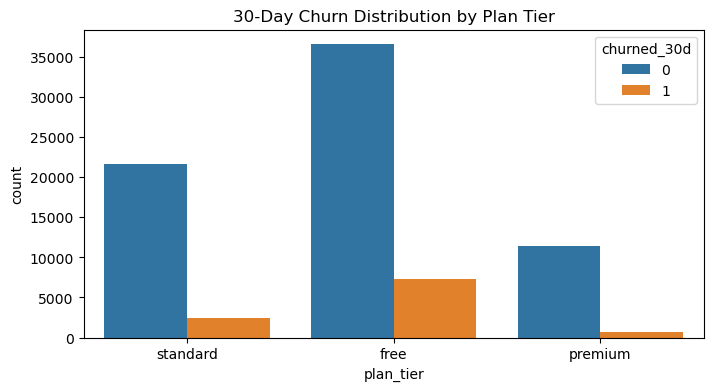

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

temp_df = X_train.copy()
temp_df[target_col] = y_train[target_col]

plt.figure(figsize=(8, 4))
sns.countplot(data=temp_df, x="plan_tier", hue=target_col)
plt.title("30-Day Churn Distribution by Plan Tier")
plt.show()


#### Categorical Feature Exploration
- Examine the distribution of data for categorical variables

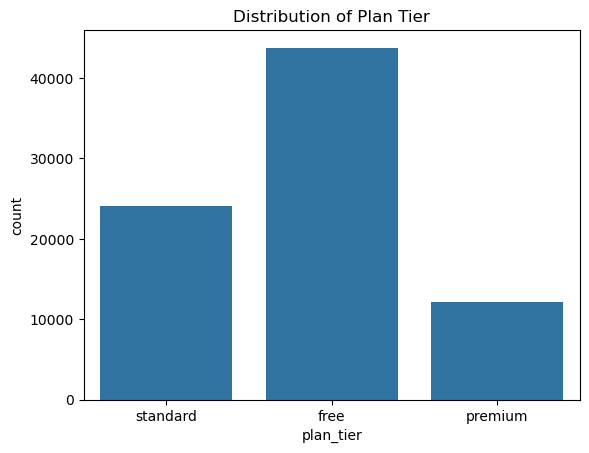

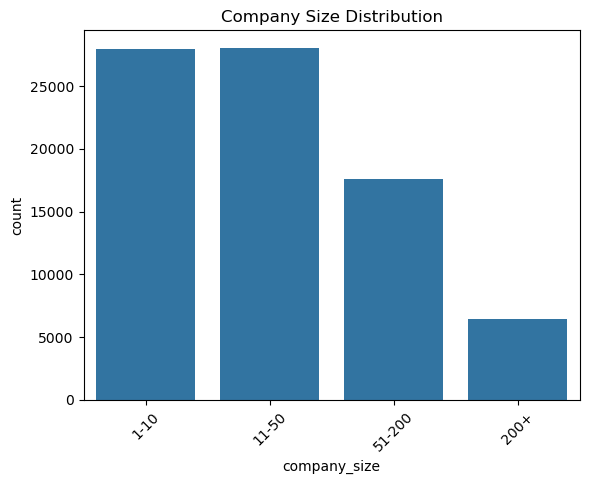

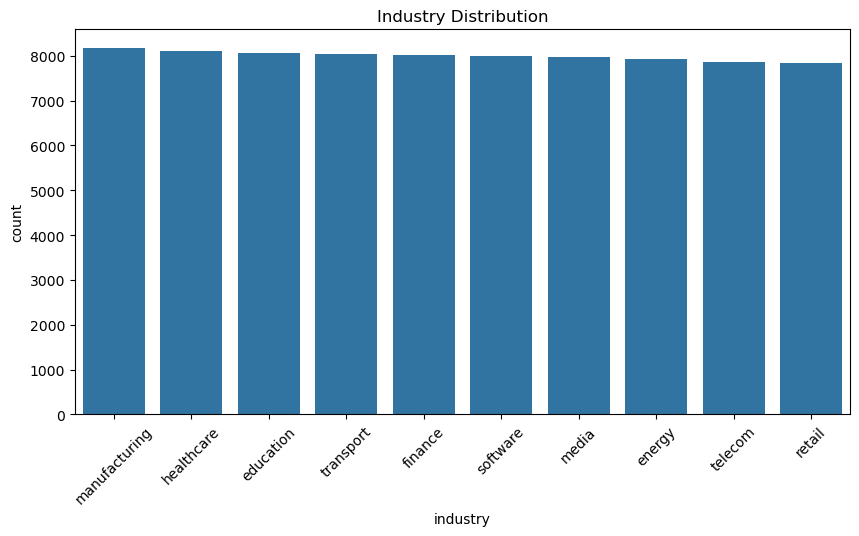

In [20]:
# Plan Tier
sns.countplot(data=temp_df, x="plan_tier")
plt.title("Distribution of Plan Tier")
plt.show()

# Company Size
size_order = ["1-10","11-50","51-200","200+"]

sns.countplot(
    data=temp_df,
    x="company_size",
    order=size_order
)

plt.xticks(rotation=45)
plt.title("Company Size Distribution")
plt.show()

# Industry
plt.figure(figsize=(10,5))

sns.countplot(
    data=temp_df,
    x="industry",
    order=temp_df["industry"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Industry Distribution")
plt.show()

#### Feature vs Churn
- Can we establish any connections between the feature variables and the target variable (Churn)?
- How can we draw on existing / external knowledge to support our observations?

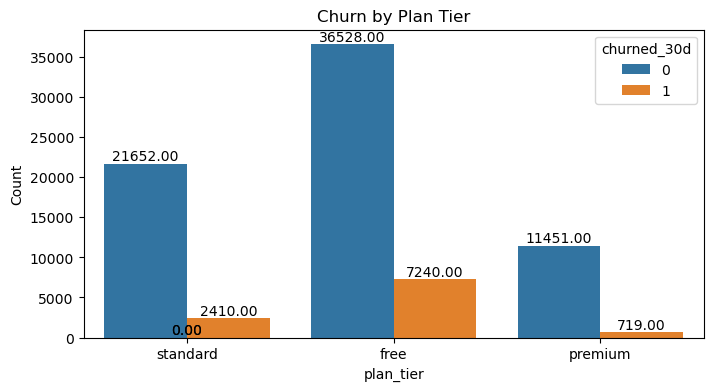

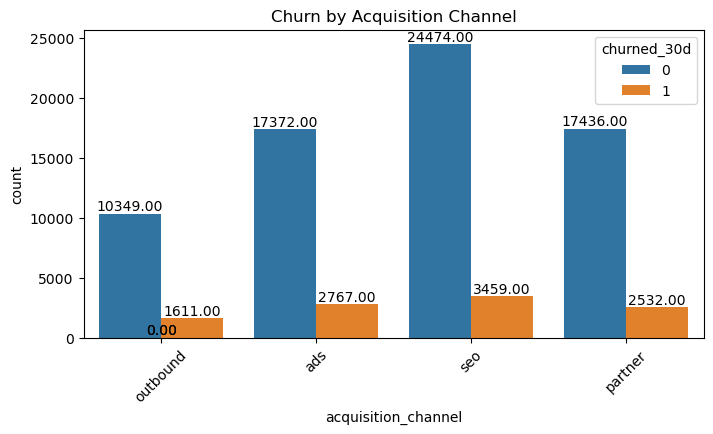

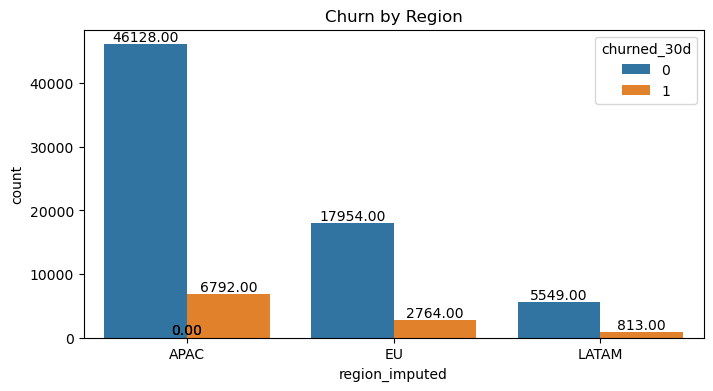

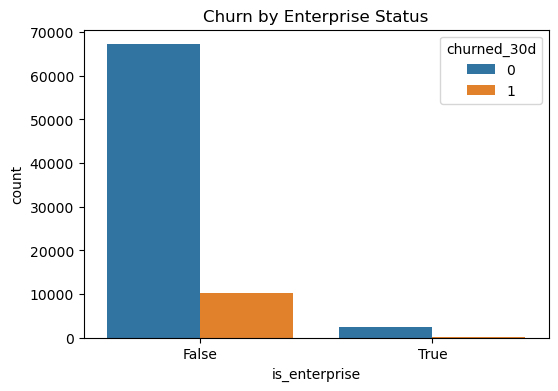

In [25]:
# Plan Tier vs Churn
plt.figure(figsize=(8,4))

ax = sns.countplot(
    data=temp_df,
    x="plan_tier",
    hue="churned_30d"
)

plt.title("Churn by Plan Tier")
plt.ylabel("Count")

# add labels above bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

# Acquisition Channel vs Churn
plt.figure(figsize=(8,4))

ax = sns.countplot(
    data=temp_df,
    x="acquisition_channel",
    hue="churned_30d"
)

plt.title("Churn by Acquisition Channel")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.show()

# Region vs Churn
plt.figure(figsize=(8,4))

ax = sns.countplot(
    data=temp_df,
    x="region_imputed",
    hue="churned_30d"
)

plt.title("Churn by Region")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.show()

# Enterprise vs Churn
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=temp_df,
    x="is_enterprise",
    hue="churned_30d"
)

plt.title("Churn by Enterprise Status")
plt.show()

#### Product Signal vs Churn
- Can we establish any connections between the product variables and the target variable (Churn)?
- How can we draw on existing / external knowledge to support our observations?

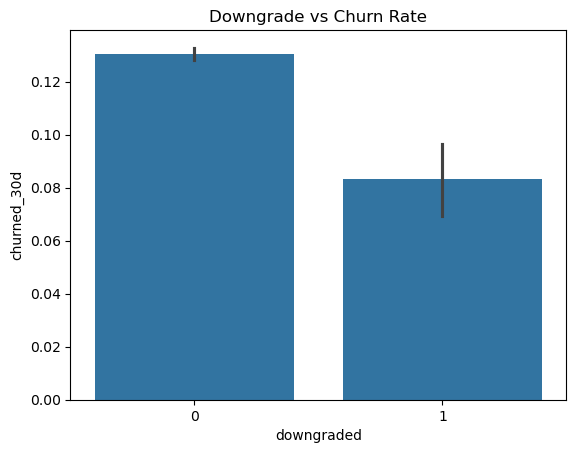

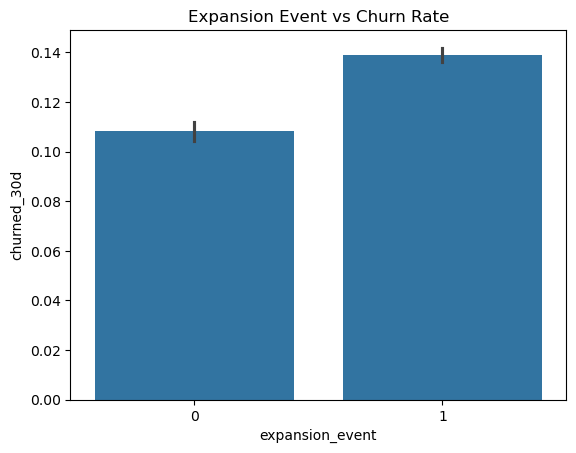

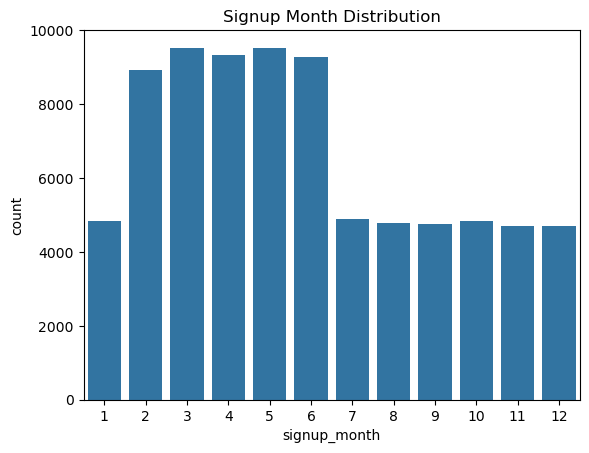

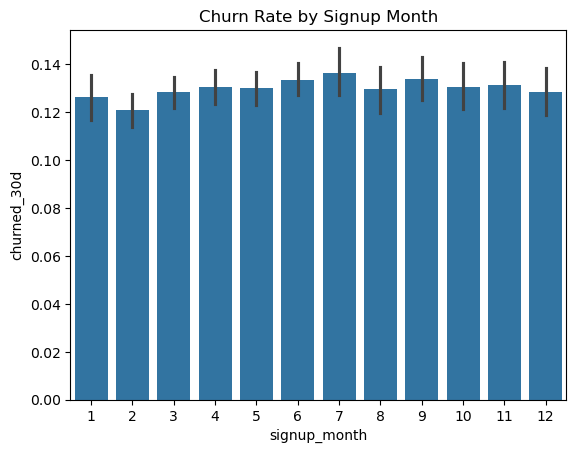

In [26]:
# Downgrades vs Churn
sns.barplot(data=temp_df, x="downgraded", y="churned_30d")

plt.title("Downgrade vs Churn Rate")
plt.show()

# Expansion Events vs Churn
sns.barplot(data=temp_df, x="expansion_event", y="churned_30d")

plt.title("Expansion Event vs Churn Rate")
plt.show()

# Sign Up Date vs Churn
# (a) Converting the format of signup_date
temp_df["signup_date"] = pd.to_datetime(temp_df["signup_date"])

temp_df["signup_month"] = temp_df["signup_date"].dt.month
temp_df["signup_year"] = temp_df["signup_date"].dt.year

# (b) Examining the distribution of signup_date
sns.countplot(data=temp_df, x="signup_month")

plt.title("Signup Month Distribution")
plt.show()

# (c) Churn by Sign up Month
sns.barplot(data=temp_df, x="signup_month", y="churned_30d")

plt.title("Churn Rate by Signup Month")
plt.show()

#### Interaction between variables?

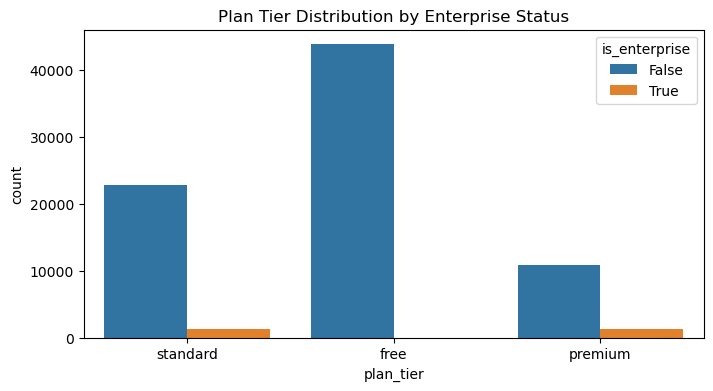

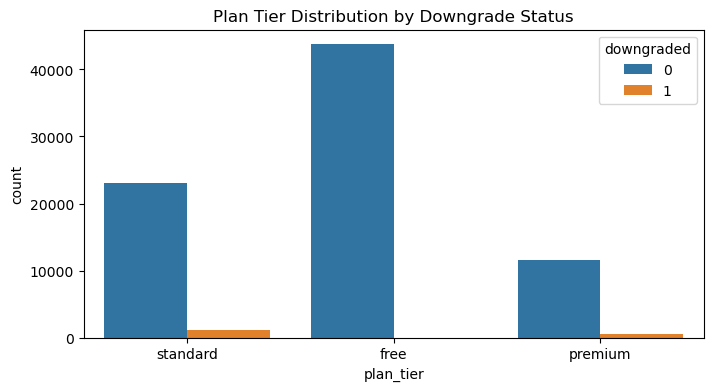

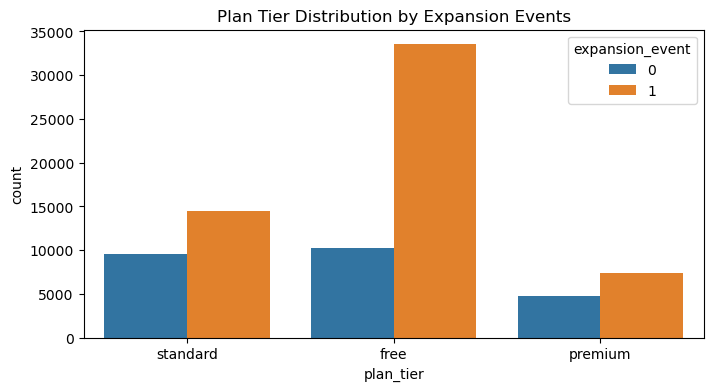

In [27]:
# Enterprise vs Plan Tier
plt.figure(figsize=(8,4))

sns.countplot(
    data=temp_df,
    x="plan_tier",
    hue="is_enterprise"
)

plt.title("Plan Tier Distribution by Enterprise Status")
plt.show()

# Downgrade vs Plan Tier
plt.figure(figsize=(8,4))

sns.countplot(
    data=temp_df,
    x="plan_tier",
    hue="downgraded"
)

plt.title("Plan Tier Distribution by Downgrade Status")
plt.show()

# Expansion vs Plan Tier
plt.figure(figsize=(8,4))

sns.countplot(
    data=temp_df,
    x="plan_tier",
    hue="expansion_event"
)

plt.title("Plan Tier Distribution by Expansion Events")
plt.show()

#### Feature Importance
- Helps examine which features may be most relevant for predicting customer churn
- Feature Importance = calculating correlations between features and the target variable
Note that correlation does not imply causation! It can help identify potential predictors that may be useful for modelling


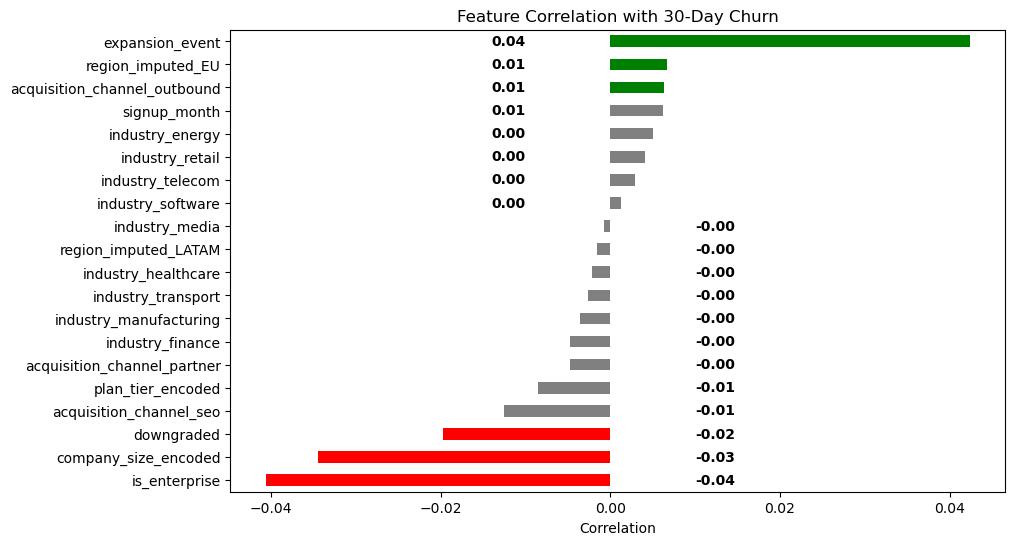

In [ ]:
# Sort correlations excluding target
feature_corr = correlations.drop("churned_30d").sort_values()

plt.figure(figsize=(10,6))

# Colors: default grey, top 3 green, bottom 3 red
colors = ["grey"] * len(feature_corr)
top3 = feature_corr.nlargest(3).index
bottom3 = feature_corr.nsmallest(3).index
for i, f in enumerate(feature_corr.index):
    if f in top3:
        colors[i] = "green"
    elif f in bottom3:
        colors[i] = "red"

# Plot horizontal bars
ax = feature_corr.plot(kind="barh", color=colors)

plt.title("Feature Correlation with 30-Day Churn")
plt.xlabel("Correlation")

# Add values next to midline 0
for i, val in enumerate(feature_corr):
    if val >= 0:
        # Positive → put text just left of 0
        ax.text(-0.01, i, f"{val:.2f}", va="center", ha="right", fontweight="bold")
    else:
        # Negative → put text just right of 0
        ax.text(0.01, i, f"{val:.2f}", va="center", ha="left", fontweight="bold")

plt.show()

### 2.2 Feature extraction

We can also change features into values that might give us more information, or values that are easier for models to compute

For example, 
- We know that "user_id" provides no meaningful information whether customers churn or not
- Our ML model cannot handle data formats, and it helps to transform it into a single numerical value
- Similarly, True/False values should be turned into 0/1 values

In [3]:
X_train = X_train.drop("user_id", axis=1)

X_train["signup_month"] = pd.to_datetime(X_train["signup_date"]).dt.month
X_train = X_train.drop("signup_date", axis=1) 

X_train['is_enterprise'] = X_train['is_enterprise'].astype(int)

X_train

,plan_tier,company_size,industry,acquisition_channel,is_enterprise,downgraded,expansion_event,region_imputed,signup_month
0,standard,1-10,energy,outbound,0,0,1,APAC,4
1,free,1-10,healthcare,ads,0,0,1,EU,6
2,free,1-10,manufacturing,ads,0,0,1,EU,4
3,standard,51-200,education,ads,0,0,0,APAC,7
4,premium,11-50,healthcare,seo,0,0,0,APAC,7
...,...,...,...,...,...,...,...,...,...
79995,free,51-200,retail,seo,0,0,1,APAC,4
79996,standard,1-10,education,seo,0,0,1,EU,5
79997,free,200+,retail,partner,0,0,0,APAC,3
79998,free,200+,manufacturing,ads,0,0,0,EU,5


### 2.3 Encoding
Similarly, ML models are bad at working with categorical data. It is much better to have them in a numerical format. 

One way to do this is through encoding, essentially labelling the different categories with different numbers. 

Nominal encoding refers to labelling while providing an order to our labels. This is helpful when order matters in our data, for example for the feature "company_size"

One hot encoding refers to labelling with no inherent order. This is useful when there is no order in our data.

In [4]:
X_train["plan_tier"].unique()

array(['standard', 'free', 'premium'], dtype=object)

In [5]:
X_train["company_size"].unique()

array(['1-10', '51-200', '11-50', '200+'], dtype=object)

In [6]:
tier_mapping = {
    "standard": 0,
    "free": 1, 
    "premium": 2
}

tier_company_size = {
    "1-10": 0, 
    "11-50": 1, 
    "51-200": 2, 
    "200+": 3
}

X_train["plan_tier_encoded"] = X_train["plan_tier"].map(tier_mapping)
X_train["company_size_encoded"] = X_train["company_size"].map(tier_company_size)

X_train = X_train.drop(columns=["plan_tier", "company_size"])

In [7]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["region_imputed", "industry", "acquisition_channel"]

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = encoder.fit_transform(X_train[cat_cols])

encoded_col_names = encoder.get_feature_names_out(cat_cols)

encoded_df = pd.DataFrame(encoded_array, columns=encoded_col_names, index=X_train.index)

X_train_encoded = pd.concat([X_train.drop(columns=cat_cols), encoded_df], axis=1)

X_train_encoded

,is_enterprise,downgraded,expansion_event,signup_month,plan_tier_encoded,company_size_encoded,region_imputed_EU,region_imputed_LATAM,industry_energy,industry_finance,industry_healthcare,industry_manufacturing,industry_media,industry_retail,industry_software,industry_telecom,industry_transport,acquisition_channel_outbound,acquisition_channel_partner,acquisition_channel_seo
0,0,0,1,4,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0,0,1,6,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,1,4,1,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,7,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,7,2,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,0,0,1,4,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
79996,0,0,1,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
79997,0,0,0,3,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
79998,0,0,0,5,1,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Correlation Analysis

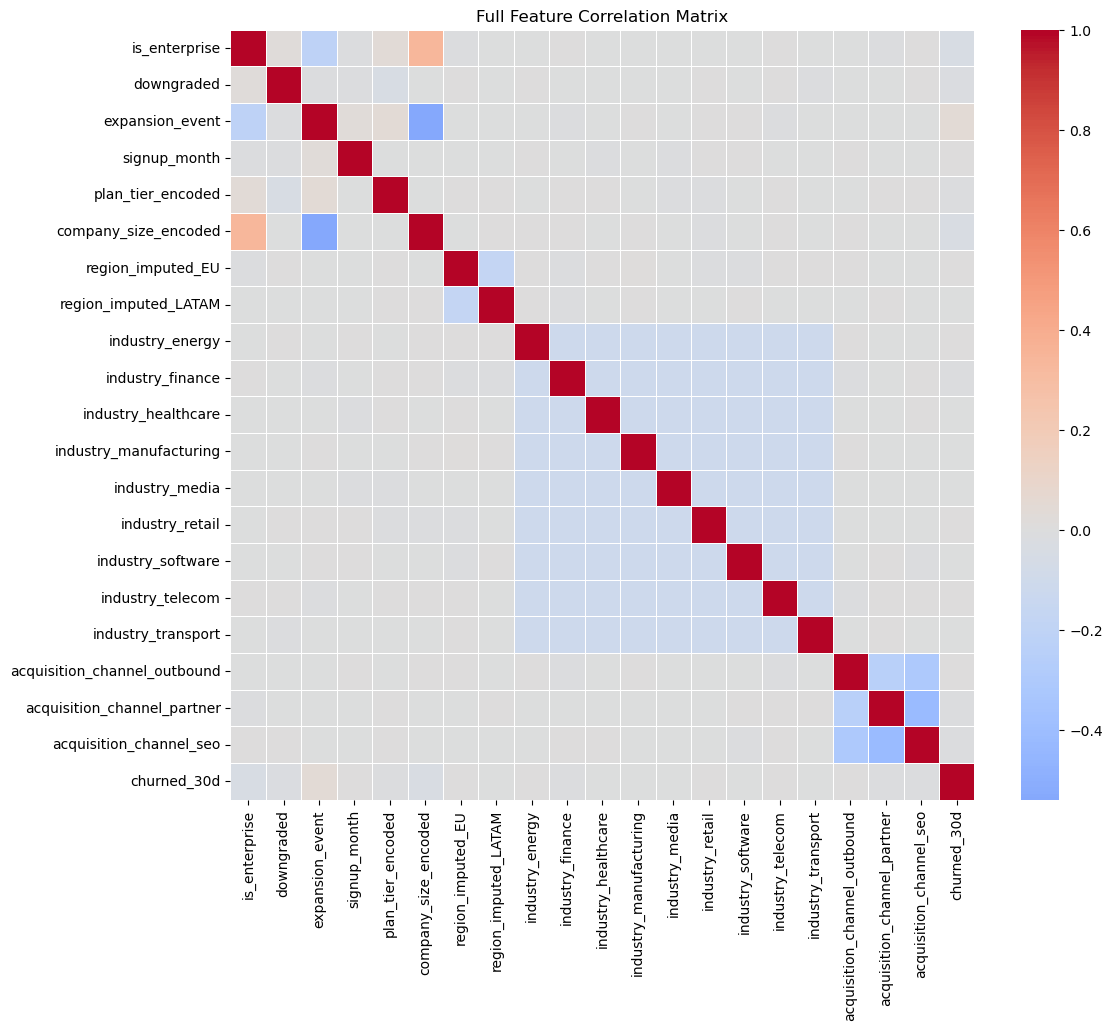

In [8]:
train_full = X_train_encoded.copy()
train_full[target_col] = y_train[target_col]

corr_matrix = train_full.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=False,    
            cmap='coolwarm', 
            center=0,
            linewidths=0.5) 

plt.title("Full Feature Correlation Matrix")
plt.show()

A lot of values have low correlation values :(

Try creating features from other datasets provided in the actual hackathon! They may convey more useful information.

In [ ]:
correlations = corr_matrix[target_col].abs()
strong_features = correlations[correlations > 0.05].index.tolist()
strong_features.remove(target_col)

print(f"Selected {len(strong_features)} features:\n{strong_features}")
X_train_final = X_train_encoded[strong_features]

Selected 0 features:
[]
